<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Requirements:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
"> 
Compatible with data_handling.py and fit_FMR_class.py (currently only Generalizing-complex-fits branch)
<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
V Original
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
"> 

In [2]:
import h5py
import numpy as np 
import sys

import matplotlib.pyplot as plt

from pathlib import Path

sys.path.append(r"C:\Users\jose1\OneDrive\PostDoc_FZU\DATA_analysis\VNA_data\VNA_analysis")
from data_handling import Analysis_FMR_HSweep, FitStore
import fit_FMR_class as models
import complex_fits as fits
import fitting_functions as funcs
import resonance_functions as res_func
import calculators as calcs

import ipywidgets as widgets
from ipywidgets import interact

from scipy.optimize import curve_fit

<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Files Information:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
">
Fill in the information about the files to be analyzed. Create a class entity for each file with Analysis_PSWS()

In [4]:
#Folders where file are. Keep the r to use raw string in Windows.
address1 = Path(r"C:\Users\jose1\OneDrive\PostDoc_FZU\DATA\joseS\20260528_Co_a\inP_along_a\3dBm\FMR_2026_08_05")

In [5]:
example_file_name_1 = "2026_08_05_FMR_Hsweep_0p285Ato5p285Ain121_3dBm_13p862GHz_17_33.h5.ma8"

In [6]:
sample = "20260528_Co_a_inP_along_a"

In [7]:
geometry = "inP" #either "inP" or "outP"

In [8]:
vna_ref_subtracted = True #Was a reference already subtracted during measurements?

In [9]:
ansy1 = Analysis_FMR_HSweep(address1, example_file_name_1, sample, "FZU_FMR_HSweep", geometry, vna_ref_subtracted)

In [10]:
store_in_origin = True #True if you wnat to store fit results in orignal file, otherwise another h5f file is created in the same directory

In [11]:
newfile_name =  (sample + f"_LorentzFits_results_{ansy1.power}dBm_slopeComp")
newfile_name = newfile_name.replace(".","p").replace("-","m")
newfile_name = newfile_name + ".h5"
newFile = address1/newfile_name
fits_storage = FitStore (newFile, val_type= 'freq', group="Lorentzian fitting")

<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Data visualization:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
">
plot_dL_slider() allows one to preview the data for each field to select the best reference subraction.

In [13]:
#ansy1.plot_dij_slider('d_S', n_0=5)

In [14]:
#Frequencies available in the data set, we can use them to find their corresponding data

In [15]:
print(ansy1.freqs)

[ 3.028  6.102  8.085  9.752 11.252 12.618 13.862 14.996 16.04  17.011
 17.93  18.811 19.674 20.527 21.375 22.217 23.05  23.874 24.68  25.467
 26.229 26.97  27.692 28.4   29.101 29.806 30.523 31.26  32.024 32.817
 33.644 34.501 35.383 36.279 37.183 38.083 38.966 39.82  40.64  41.418]


In [16]:
float(ansy1.freqs[9])

17.011

In [17]:
# Example of a single fit

{'Ar': -3.015341448557511e-07, 'Ai': -3.495703138704182e-06, 'Ho': 0.875, 'dH': 0.00023257006398472147, 'm': 0.0021982520136615193, 're0': 0.0038, 'im0': -0.003}
Initial simplex fit


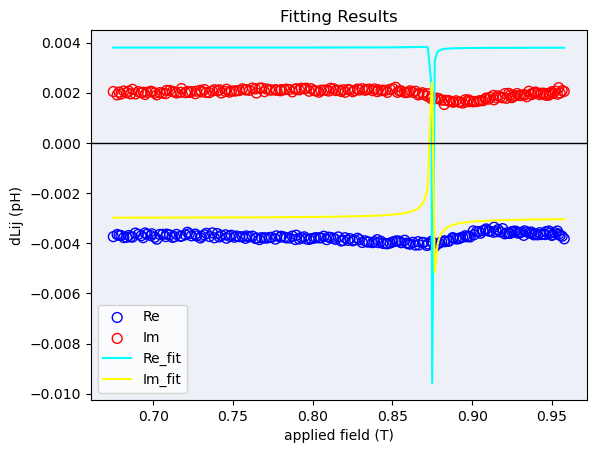

Final fit and results


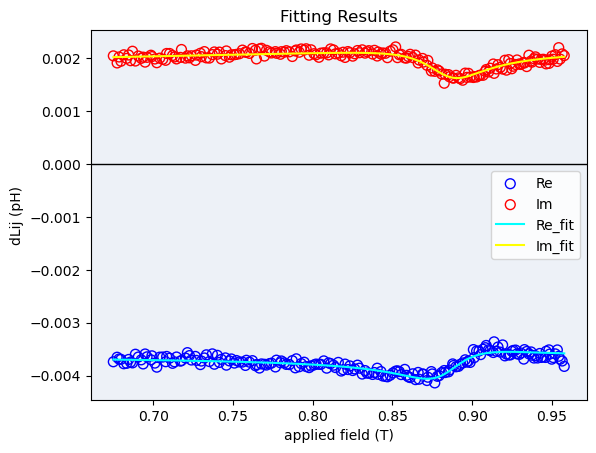


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.015e-05      5.703e-07         U        No
Ai                    -5.889e-06      5.431e-07         U        No
Ho                        0.8847         0.0011         T        No
dH                        0.0227         0.0011         T        No
m                       -31.3157         3.5738       1/T        No
re0                      -0.0036      2.446e-05         U        No
im0                       0.0017      5.756e-05         U        No
----------------------------------------------------------------------
The phase is: 329.88374204075336


In [199]:
ini_vals = [0.05, 0.05, 0.152, 0.0001, 0, 0, 0] #Ar, Ai, Ho, dH, re0, im0
freq = 39.82
f_index = int(np.where(ansy1.freqs == freq)[0][0])
H_center = 0.875

H_min, H_max = H_center-0.25, H_center+0.25 #T
h_array = ansy1.get_field(freq)

y_array_re, y_array_im = ansy1.d_S("21R", freq), ansy1.d_S("21I", freq)

model = models.ComplexLorentzian_slope_field()
fitter = fits.ComplexFitter( ini_vals, H_min, H_max,
    h_array, y_array_re , y_array_im, model)
fitter.fix(Ho=H_center, re0=0.0038, im0=-0.003) # Parameters to be fixed, empty otherwise
opt_p0 = fitter.simplex_wpm(method='Nelder-Mead')#'Powell'
print(opt_p0)
print("Initial simplex fit")
fitter.plot_fit_simplex_wpm()

new_p0 = np.array(list(opt_p0.values()), dtype=float)
fitter.update_p0(new_p0)

#fitter.fix(dH=0.01)#, ) re0=0.0038, im0=-0.003)

params, cov = fitter.fit(simplex_b=False)
print("Final fit and results")
fitter.plot_fit()
fitter.summary()
print(f"The phase is: {model.phase_deg(**params)}")

In [19]:
#If we are happy with the fit, we can save it.

In [201]:
fit_dict = fitter.export_fit_dict()

fits_storage.save(index=f_index, val=float(ansy1.freqs[f_index]), fit_dict=fit_dict)

In [21]:
fit_dict["params"]["Ho"]

0.16116838040278966

In [22]:
# Automatic fitting of entire spectra. Enter the estimated parameters for the Kittel model guiding the automatic fitting.

Index= 0, freq.=3.028 GHz, Guide field.=0.017285501604740072


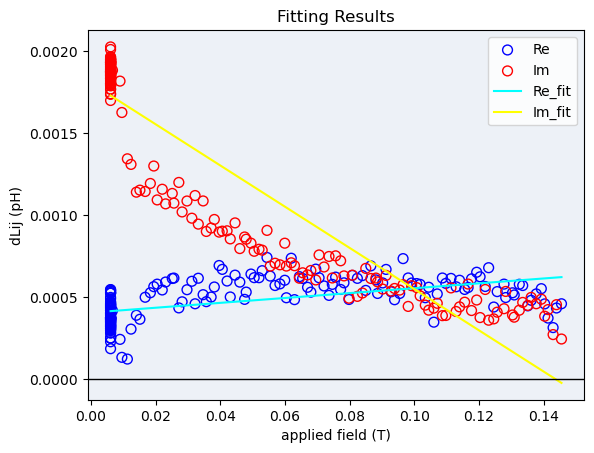


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -7.285e-06      8.075e-06         U        No
Ai                     5.745e-06      8.098e-06         U        No
Ho                        2.0000      4.387e+03         T        No
dH                        0.2000      4.383e+03         T        No
m                      -963.7695         2.9432       1/T        No
re0                    4.018e-04         0.0101         U        No
im0                       0.0018         0.0101         U        No
----------------------------------------------------------------------
Index= 1, freq.=6.102 GHz, Guide field.=0.03916580875794373


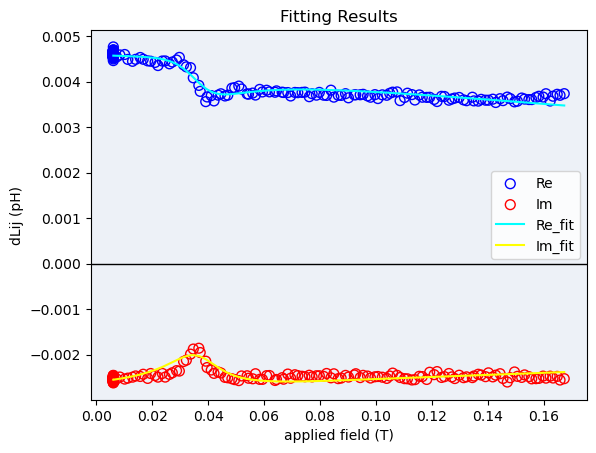


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -7.441e-06      4.485e-07         U        No
Ai                    -3.083e-06      1.325e-07         U        No
Ho                        0.0367      4.856e-04         T        No
dH                        0.0120      7.109e-04         T        No
m                       507.0231        34.4393       1/T        No
re0                       0.0044      1.233e-05         U        No
im0                      -0.0027      1.344e-05         U        No
----------------------------------------------------------------------
Index= 2, freq.=8.085 GHz, Guide field.=0.060502243955509405


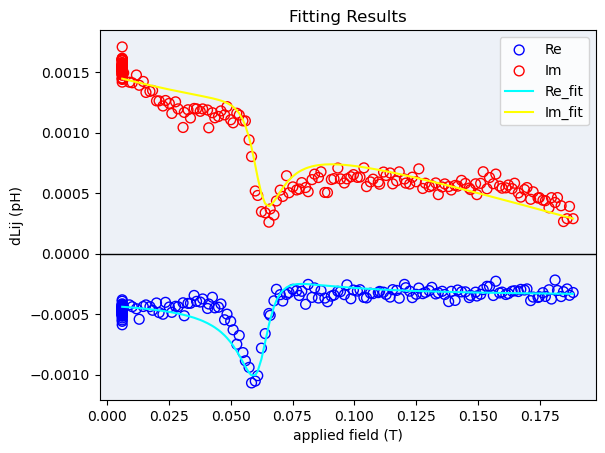


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.800e-06      1.764e-07         U        No
Ai                    -3.772e-06      2.269e-07         U        No
Ho                        0.0621      3.063e-04         T        No
dH                        0.0070      4.496e-04         T        No
m                       773.0543        47.2809       1/T        No
re0                   -3.645e-04      1.107e-05         U        No
im0                       0.0014      9.962e-06         U        No
----------------------------------------------------------------------
Index= 3, freq.=9.752 GHz, Guide field.=0.08245542754150892


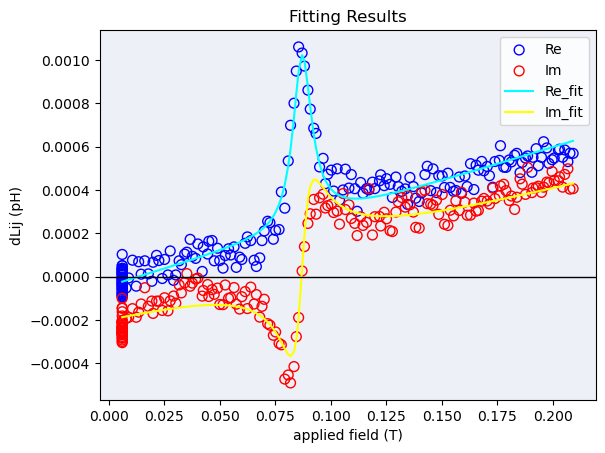


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.752e-07      5.770e-08         U        No
Ai                     4.046e-06      1.419e-07         U        No
Ho                        0.0868      1.666e-04         T        No
dH                        0.0052      2.359e-04         T        No
m                       717.4112        31.0912       1/T        No
re0                   -4.051e-05      6.369e-06         U        No
im0                   -1.525e-04      7.483e-06         U        No
----------------------------------------------------------------------
Index= 4, freq.=11.252 GHz, Guide field.=0.10509831720792928


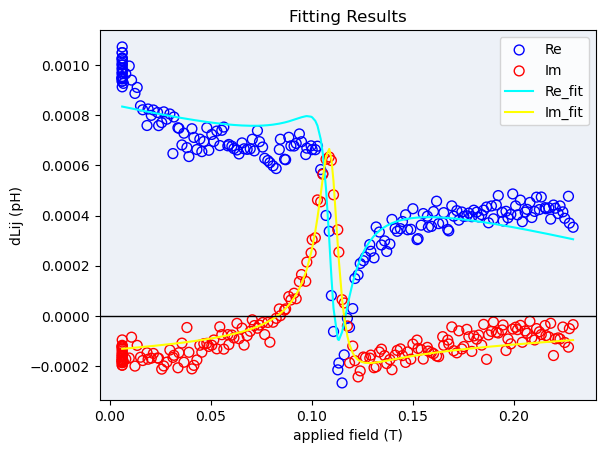


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.190e-06      1.888e-07         U        No
Ai                    -2.850e-06      1.272e-07         U        No
Ho                        0.1102      2.342e-04         T        No
dH                        0.0059      2.937e-04         T        No
m                       288.9209        18.2715       1/T        No
re0                    8.083e-04      1.008e-05         U        No
im0                   -1.636e-04      7.990e-06         U        No
----------------------------------------------------------------------
Index= 5, freq.=12.618 GHz, Guide field.=0.12791380767232685


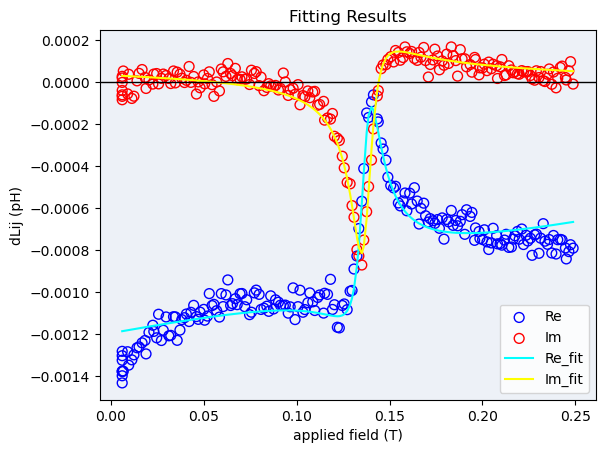


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     4.792e-06      1.622e-07         U        No
Ai                     3.948e-06      1.231e-07         U        No
Ho                        0.1371      1.867e-04         T        No
dH                        0.0064      2.277e-04         T        No
m                       207.2076        10.8296       1/T        No
re0                      -0.0012      9.177e-06         U        No
im0                    6.217e-05      6.736e-06         U        No
----------------------------------------------------------------------
Index= 6, freq.=13.862 GHz, Guide field.=0.1503733342021688


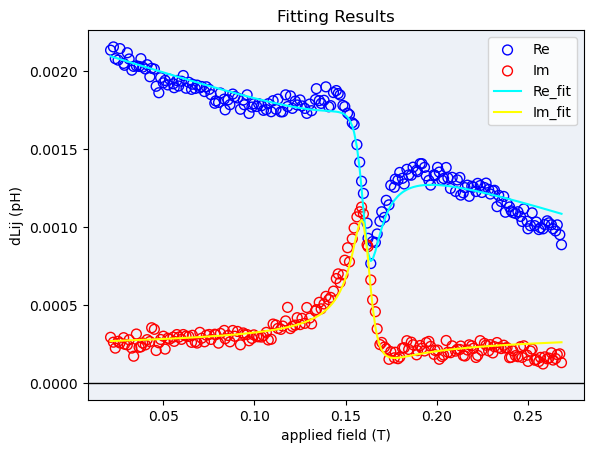


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.045e-06      1.481e-07         U        No
Ai                    -3.631e-06      1.161e-07         U        No
Ho                        0.1612      1.803e-04         T        No
dH                        0.0061      2.508e-04         T        No
m                       496.5915        20.8697       1/T        No
re0                       0.0021      1.079e-05         U        No
im0                    2.374e-04      9.411e-06         U        No
----------------------------------------------------------------------
Index= 7, freq.=14.996 GHz, Guide field.=0.17214104938951924


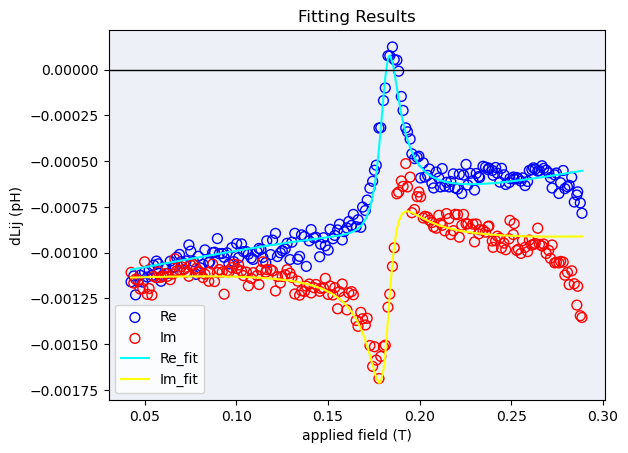


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.928e-06      1.713e-07         U        No
Ai                     5.242e-06      1.858e-07         U        No
Ho                        0.1819      2.367e-04         T        No
dH                        0.0065      2.959e-04         T        No
m                       243.8675        15.5188       1/T        No
re0                      -0.0012      1.392e-05         U        No
im0                      -0.0011      1.212e-05         U        No
----------------------------------------------------------------------
Index= 8, freq.=16.04 GHz, Guide field.=0.19319620239986623


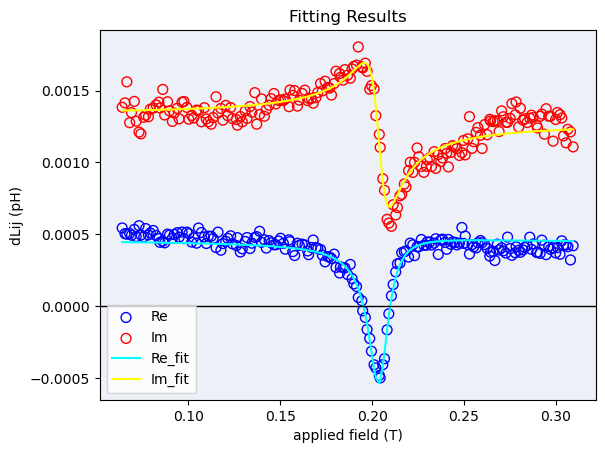


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.447e-06      1.644e-07         U        No
Ai                    -6.438e-06      1.808e-07         U        No
Ho                        0.2041      2.202e-04         T        No
dH                        0.0066      2.266e-04         T        No
m                        12.1631         7.8309       1/T        No
re0                    4.621e-04      8.092e-06         U        No
im0                       0.0013      1.303e-05         U        No
----------------------------------------------------------------------
Index= 9, freq.=17.011 GHz, Guide field.=0.21359475663892125


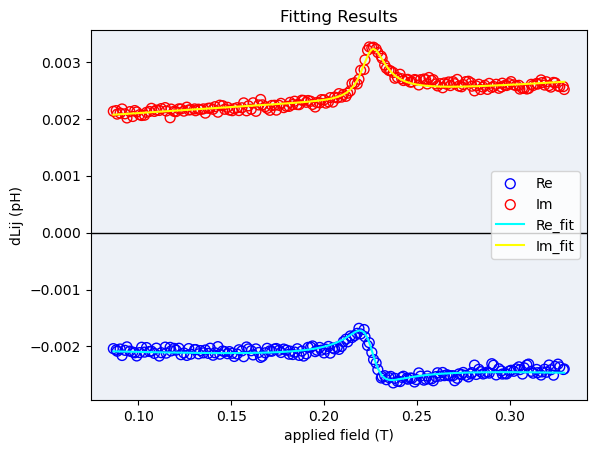


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -6.390e-06      1.648e-07         U        No
Ai                     2.136e-06      1.198e-07         U        No
Ho                        0.2253      1.978e-04         T        No
dH                        0.0079      2.589e-04         T        No
m                       261.2949        11.4868       1/T        No
re0                      -0.0020      1.205e-05         U        No
im0                       0.0019      1.180e-05         U        No
----------------------------------------------------------------------
Index= 10, freq.=17.93 GHz, Guide field.=0.23357943630339184


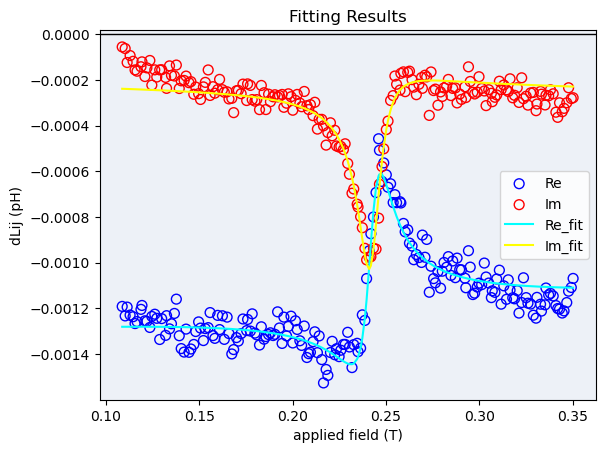


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     5.428e-06      1.763e-07         U        No
Ai                     2.449e-06      1.484e-07         U        No
Ho                        0.2425      2.484e-04         T        No
dH                        0.0072      2.617e-04         T        No
m                        41.8822         8.6195       1/T        No
re0                      -0.0013      1.596e-05         U        No
im0                   -2.052e-04      6.692e-06         U        No
----------------------------------------------------------------------
Index= 11, freq.=18.811 GHz, Guide field.=0.253319899998698


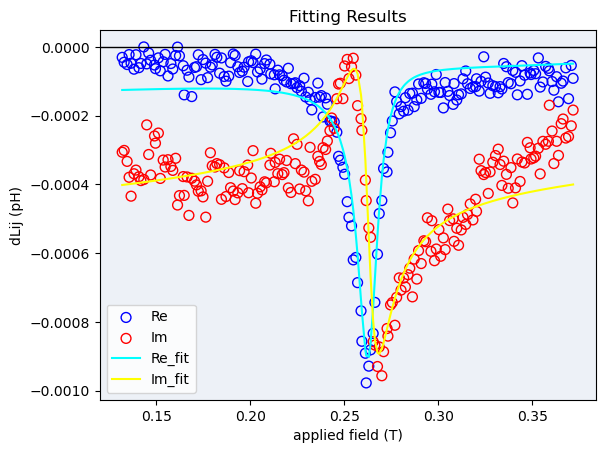


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.107e-06      1.964e-07         U        No
Ai                    -5.281e-06      1.951e-07         U        No
Ho                        0.2631      3.002e-04         T        No
dH                        0.0065      2.958e-04         T        No
m                       -58.9622        10.3556       1/T        No
re0                   -1.474e-04      1.318e-05         U        No
im0                   -4.913e-04      1.824e-05         U        No
----------------------------------------------------------------------
Index= 12, freq.=19.674 GHz, Guide field.=0.2731771779140407


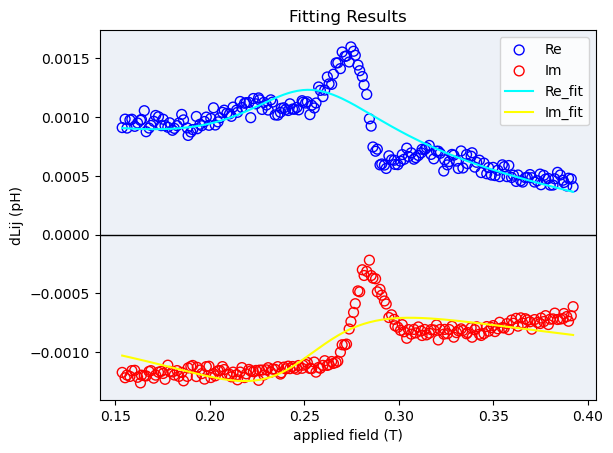


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.139e-05      2.236e-06         U        No
Ai                     3.061e-05      4.421e-06         U        No
Ho                        0.2485         0.0033         T        No
dH                        0.0498         0.0043         T        No
m                       -63.9580         9.1963       1/T        No
re0                       0.0013      9.536e-05         U        No
im0                   -5.377e-04      4.689e-05         U        No
----------------------------------------------------------------------
Index= 13, freq.=20.527 GHz, Guide field.=0.29328110993250267


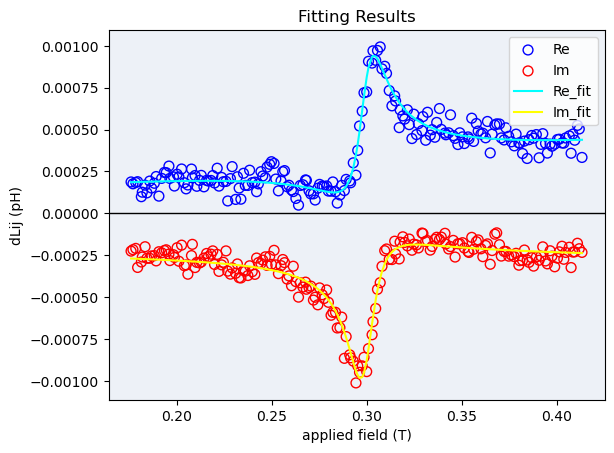


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     5.566e-06      1.727e-07         U        No
Ai                     3.778e-06      1.343e-07         U        No
Ho                        0.2992      2.374e-04         T        No
dH                        0.0084      2.587e-04         T        No
m                        71.7114         7.2570       1/T        No
re0                    1.111e-04      1.828e-05         U        No
im0                   -2.137e-04      6.359e-06         U        No
----------------------------------------------------------------------
Index= 14, freq.=21.375 GHz, Guide field.=0.3137101988534209


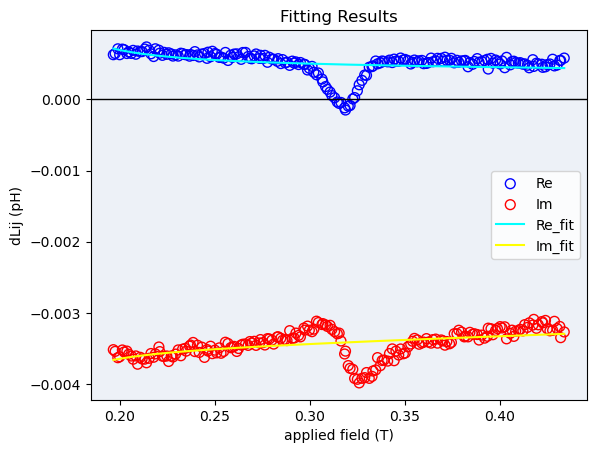


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.236e-05      2.487e-05         U        No
Ai                    -8.407e-06      2.578e-05         U        No
Ho                        0.1525         0.0745         T        No
dH                     1.000e-04         0.0227         T        No
m                       -41.8035       129.5782       1/T        No
re0                    4.687e-04      3.105e-04         U        No
im0                      -0.0036      3.294e-04         U        No
----------------------------------------------------------------------
Index= 15, freq.=22.217 GHz, Guide field.=0.33440696115029145


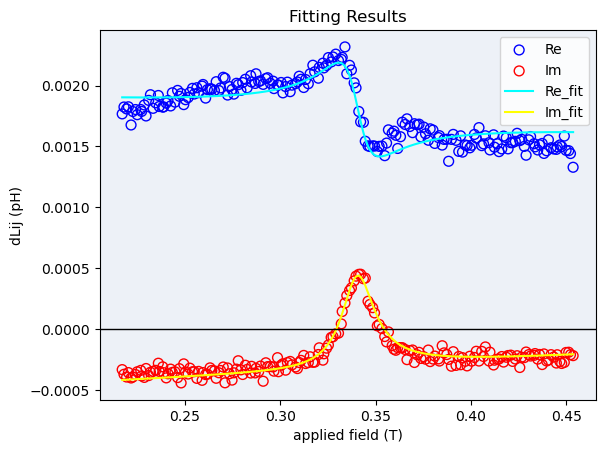


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -7.874e-06      2.814e-07         U        No
Ai                     9.327e-07      2.310e-07         U        No
Ho                        0.3401      3.995e-04         T        No
dH                        0.0105      4.611e-04         T        No
m                        93.3212         9.9485       1/T        No
re0                       0.0020      2.484e-05         U        No
im0                   -5.924e-04      2.136e-05         U        No
----------------------------------------------------------------------
Index= 16, freq.=23.05 GHz, Guide field.=0.355263912031485


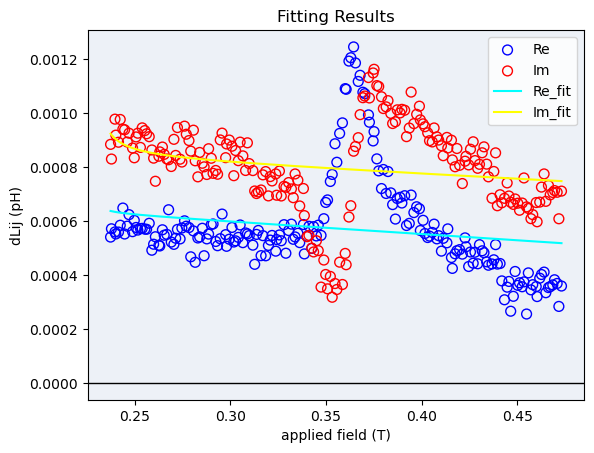


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.152e-07      8.917e-07         U        No
Ai                     9.910e-07      4.173e-06         U        No
Ho                        0.2268         0.0442         T        No
dH                     1.000e-04         0.0135         T        No
m                      -414.1354      1.938e+03       1/T        No
re0                    7.348e-04      7.554e-05         U        No
im0                    9.164e-04      1.673e-04         U        No
----------------------------------------------------------------------
Index= 17, freq.=23.874 GHz, Guide field.=0.376247929051723


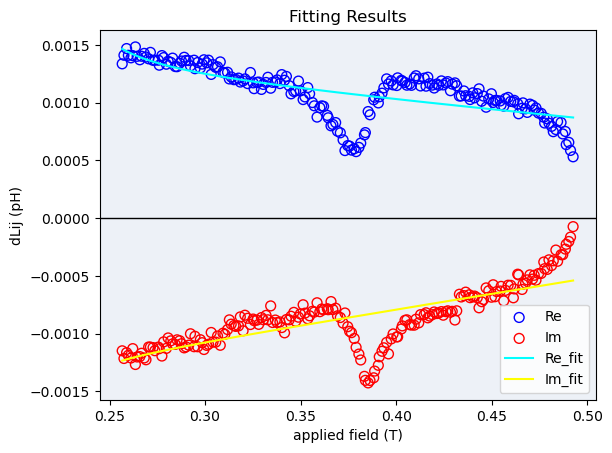


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     8.957e-06      2.103e-05         U        No
Ai                    -2.419e-06      7.027e-06         U        No
Ho                        0.2228         0.0622         T        No
dH                     1.000e-04         0.0126         T        No
m                      -234.7099       596.2469       1/T        No
re0                       0.0016      3.654e-04         U        No
im0                      -0.0018      1.516e-04         U        No
----------------------------------------------------------------------
Index= 18, freq.=24.68 GHz, Guide field.=0.3970940332845617


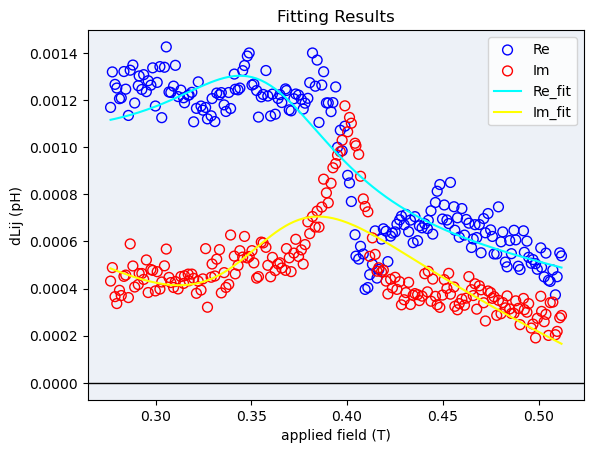


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -9.608e-06      4.379e-06         U        No
Ai                     3.104e-05      4.436e-06         U        No
Ho                        0.3577         0.0033         T        No
dH                        0.0569         0.0064         T        No
m                       -74.9946        14.2351       1/T        No
re0                       0.0013      1.509e-04         U        No
im0                       0.0015      5.801e-05         U        No
----------------------------------------------------------------------
Index= 19, freq.=25.467 GHz, Guide field.=0.41773810752207974


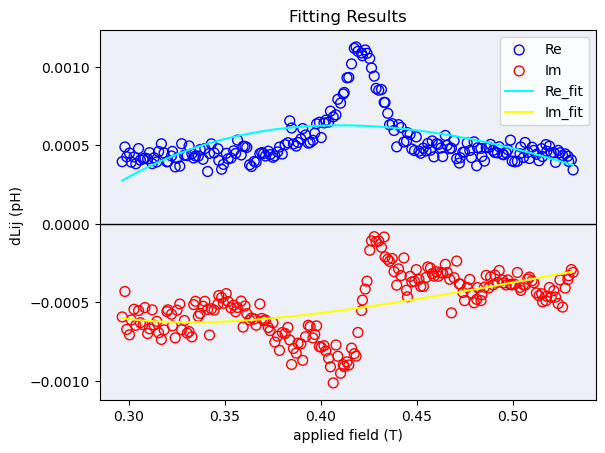


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                       -0.0014         0.0031         U        No
Ai                       -0.0011         0.0029         U        No
Ho                     2.581e-19         0.3061         T        No
dH                        0.1301         0.1323         T        No
m                         3.8515         6.1626       1/T        No
re0                       0.0084         0.0093         U        No
im0                    3.580e-04         0.0032         U        No
----------------------------------------------------------------------
Index= 20, freq.=26.229 GHz, Guide field.=0.43798462163181184


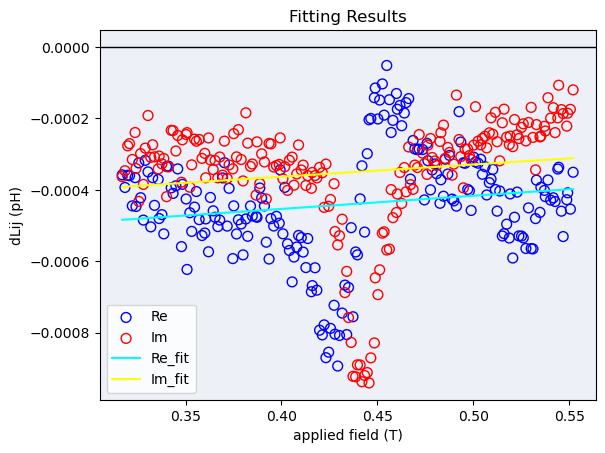


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.267e-08      6.148e-07         U        No
Ai                    -3.537e-07      6.148e-07         U        No
Ho                     2.324e-25       126.4510         T        No
dH                        0.2000       126.4516         T        No
m                      -999.9002         0.0196       1/T        No
re0                   -5.995e-04      5.651e-04         U        No
im0                   -4.990e-04      5.651e-04         U        No
----------------------------------------------------------------------
Index= 21, freq.=26.97 GHz, Guide field.=0.45790448917170645


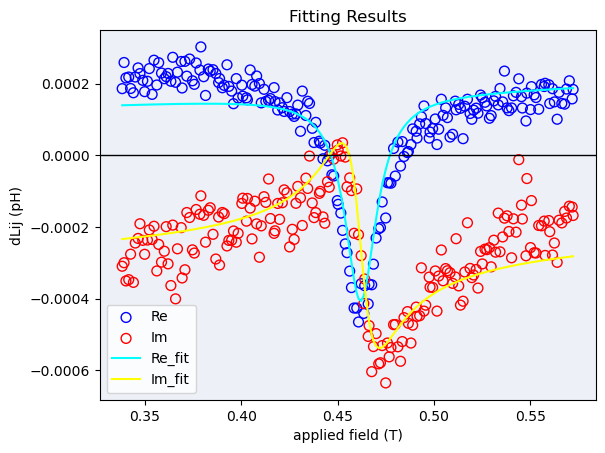


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.309e-08      2.579e-07         U        No
Ai                    -5.698e-06      2.488e-07         U        No
Ho                        0.4619      5.411e-04         T        No
dH                        0.0099      5.300e-04         T        No
m                       -36.8914        10.0363       1/T        No
re0                    7.186e-05      2.889e-05         U        No
im0                   -3.500e-04      2.740e-05         U        No
----------------------------------------------------------------------
Index= 22, freq.=27.692 GHz, Guide field.=0.47752225641837354


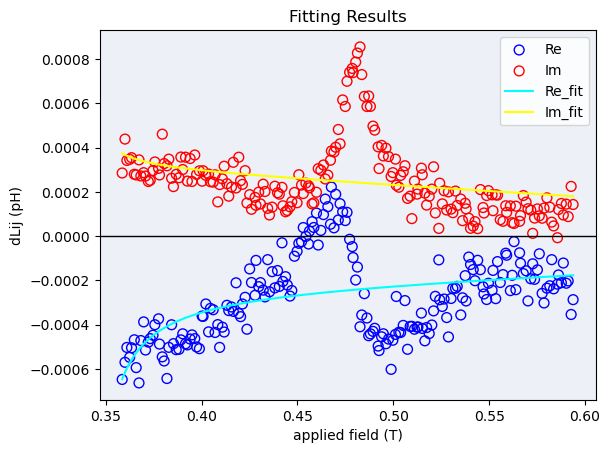


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -7.952e-06      8.118e-06         U        No
Ai                     1.469e-06      4.460e-06         U        No
Ho                        0.3395         0.0186         T        No
dH                     1.000e-04         0.0085         T        No
m                       -54.0856        93.0267       1/T        No
re0                   -3.535e-04      2.561e-04         U        No
im0                    4.768e-04      1.531e-04         U        No
----------------------------------------------------------------------
Index= 23, freq.=28.4 GHz, Guide field.=0.49695012921485293


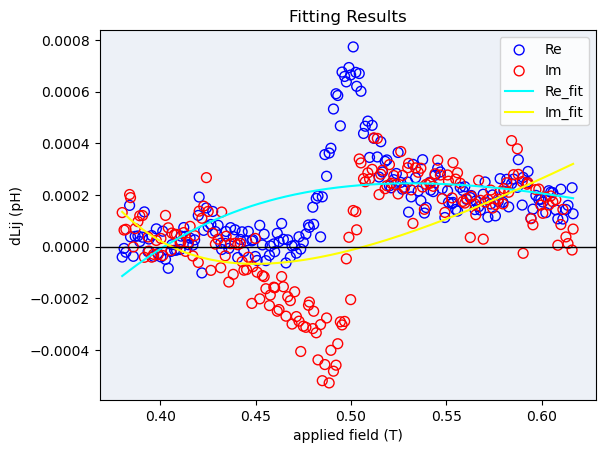


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.428e-04      5.304e-04         U        No
Ai                     5.011e-05      4.345e-05         U        No
Ho                        0.2388         0.1080         T        No
dH                        0.0569         0.0485         T        No
m                        11.5076        12.0570       1/T        No
re0                       0.0031         0.0027         U        No
im0                      -0.0027         0.0011         U        No
----------------------------------------------------------------------
Index= 24, freq.=29.101 GHz, Guide field.=0.516363155204513


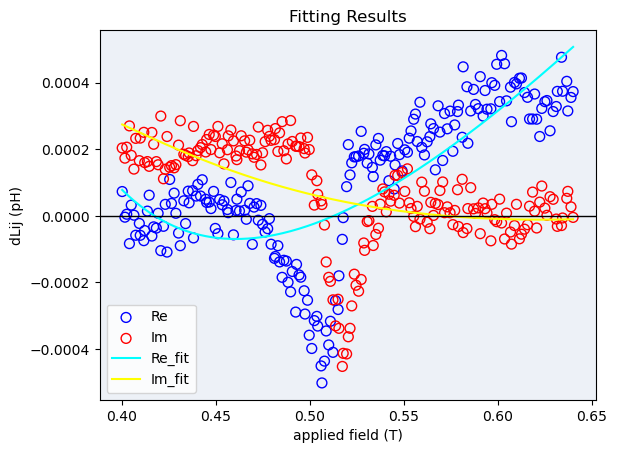


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.744e-04      3.547e-04         U        No
Ai                     5.090e-04      8.646e-04         U        No
Ho                        0.2082         0.1461         T        No
dH                        0.0723         0.0577         T        No
m                         9.2892        11.1041       1/T        No
re0                      -0.0050         0.0026         U        No
im0                      -0.0024         0.0028         U        No
----------------------------------------------------------------------
Index= 25, freq.=29.806 GHz, Guide field.=0.5360566946168036


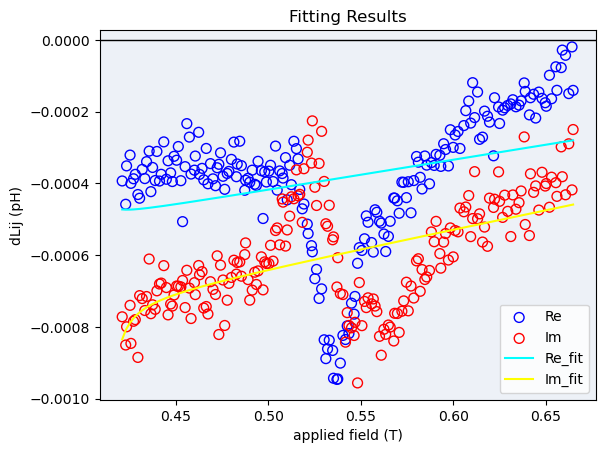


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.120e-07      2.440e-07         U        No
Ai                    -9.515e-07      2.801e-06         U        No
Ho                        0.4129         0.0252         T        No
dH                     1.000e-04         0.0078         T        No
m                     -1000.0000      3.064e+03       1/T        No
re0                   -8.384e-04      9.196e-05         U        No
im0                      -0.0012      1.858e-04         U        No
----------------------------------------------------------------------
Index= 26, freq.=30.523 GHz, Guide field.=0.5562520795700049


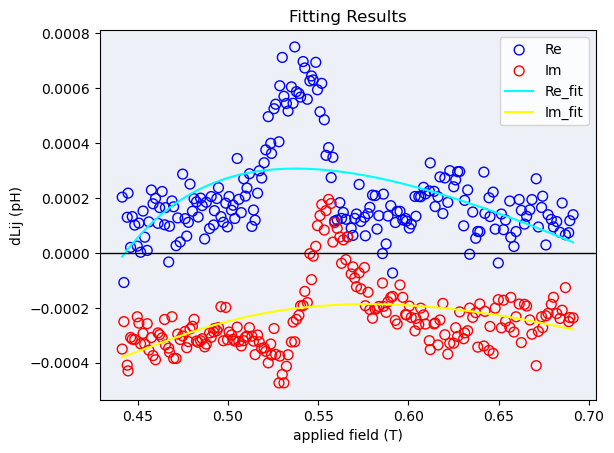


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.356e-05      3.405e-05         U        No
Ai                    -3.115e-04      3.546e-04         U        No
Ho                        0.3128         0.0790         T        No
dH                        0.0790         0.0377         T        No
m                        11.1470         8.2347       1/T        No
re0                       0.0027         0.0011         U        No
im0                       0.0028         0.0018         U        No
----------------------------------------------------------------------
Index= 27, freq.=31.26 GHz, Guide field.=0.5771778776994335


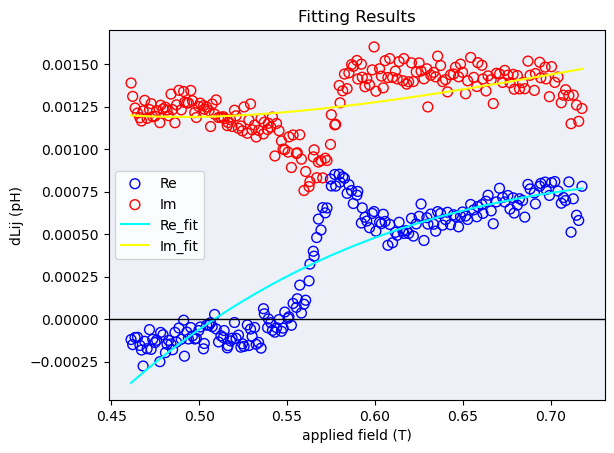


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                       -0.0029         0.0090         U        No
Ai                       -0.0016         0.0106         U        No
Ho                     3.630e-16         0.6606         T        No
dH                        0.1567         0.4852         T        No
m                         1.0723         1.9364       1/T        No
re0                       0.0086         0.0199         U        No
im0                       0.0018         0.0115         U        No
----------------------------------------------------------------------
Index= 28, freq.=32.024 GHz, Guide field.=0.5990407164706225


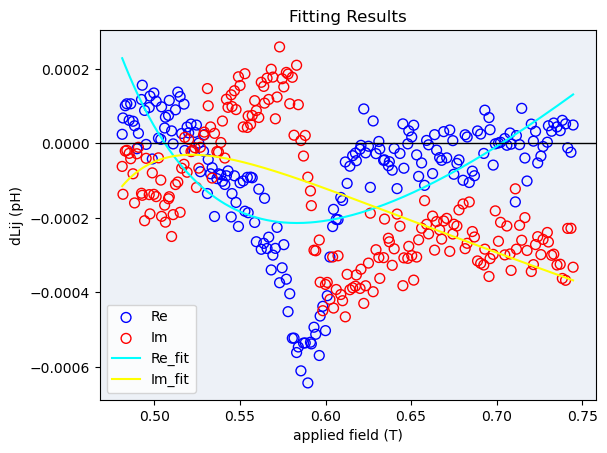


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.655e-04      1.110e-04         U        No
Ai                     9.708e-05      8.784e-05         U        No
Ho                        0.3881         0.0394         T        No
dH                        0.0459         0.0189         T        No
m                        18.1315         9.1901       1/T        No
re0                      -0.0039         0.0012         U        No
im0                    3.467e-04      4.368e-04         U        No
----------------------------------------------------------------------
Index= 29, freq.=32.817 GHz, Guide field.=0.6219081063726856


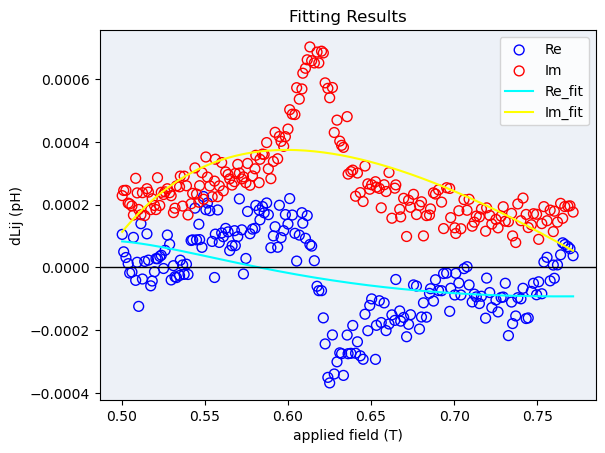


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.575e-04      4.594e-04         U        No
Ai                    -1.970e-04      2.033e-04         U        No
Ho                        0.3286         0.1052         T        No
dH                        0.0838         0.0474         T        No
m                         8.1853         6.8464       1/T        No
re0                      -0.0018         0.0015         U        No
im0                       0.0041         0.0018         U        No
----------------------------------------------------------------------
Index= 30, freq.=33.644 GHz, Guide field.=0.6459361092555128


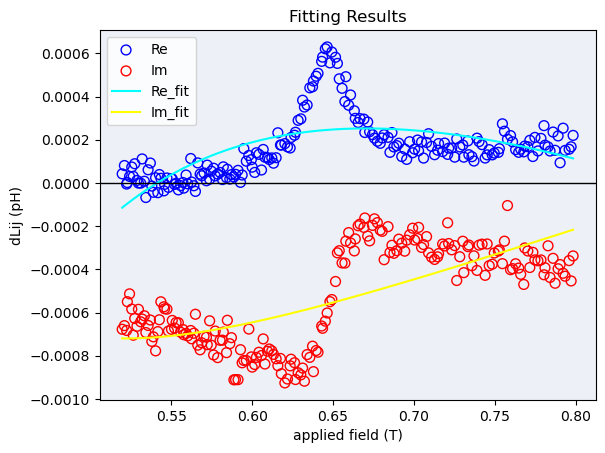


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -8.454e-04         0.0016         U        No
Ai                    -3.155e-04         0.0010         U        No
Ho                        0.2451         0.2543         T        No
dH                        0.0799         0.1098         T        No
m                         4.1460         6.0650       1/T        No
re0                       0.0055         0.0056         U        No
im0                      -0.0016         0.0016         U        No
----------------------------------------------------------------------
Index= 31, freq.=34.501 GHz, Guide field.=0.6710199610672224


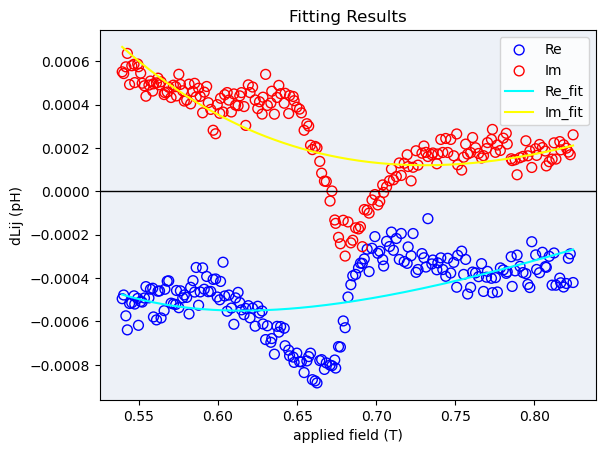


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                       -0.0020         0.0057         U        No
Ai                        0.0032         0.0078         U        No
Ho                        0.0836         0.4710         T        No
dH                        0.2000         0.2094         T        No
m                         1.5829         2.4672       1/T        No
re0                   -4.667e-04         0.0032         U        No
im0                      -0.0114         0.0156         U        No
----------------------------------------------------------------------
Index= 32, freq.=35.383 GHz, Guide field.=0.6970211313761191


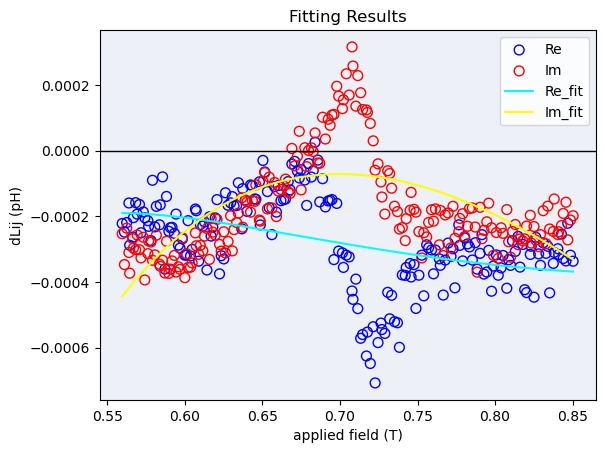


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                        0.0022         0.0041         U        No
Ai                       -0.0011         0.0020         U        No
Ho                        0.1802         0.3059         T        No
dH                        0.1867         0.1331         T        No
m                         2.2411         2.7082       1/T        No
re0                      -0.0049         0.0055         U        No
im0                       0.0084         0.0074         U        No
----------------------------------------------------------------------
Index= 33, freq.=36.279 GHz, Guide field.=0.7236175804668316


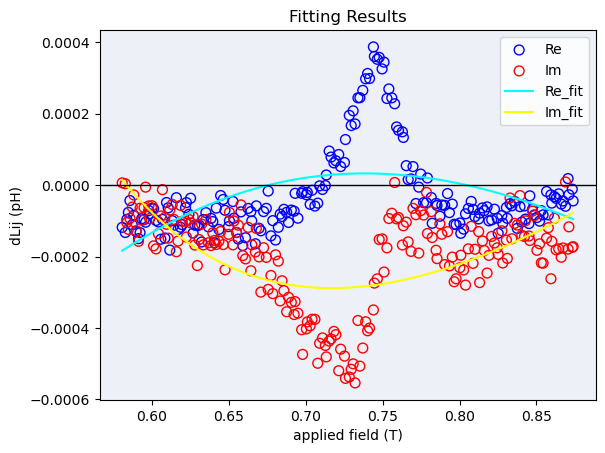


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                       -0.0022         0.0037         U        No
Ai                    -4.239e-04      7.536e-04         U        No
Ho                        0.2163         0.2700         T        No
dH                        0.2000         0.1171         T        No
m                         2.3408         2.5459       1/T        No
re0                       0.0085         0.0072         U        No
im0                      -0.0041         0.0027         U        No
----------------------------------------------------------------------
Index= 34, freq.=37.183 GHz, Guide field.=0.7506280426450865


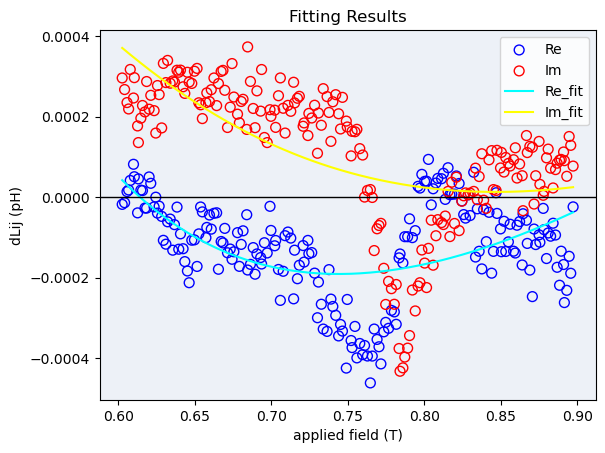


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.798e-04         0.0010         U        No
Ai                        0.0024         0.0067         U        No
Ho                        0.1698         0.5117         T        No
dH                        0.2000         0.2282         T        No
m                         1.6445         2.8322       1/T        No
re0                      -0.0039         0.0041         U        No
im0                      -0.0069         0.0114         U        No
----------------------------------------------------------------------
Index= 35, freq.=38.083 GHz, Guide field.=0.7776858109117352


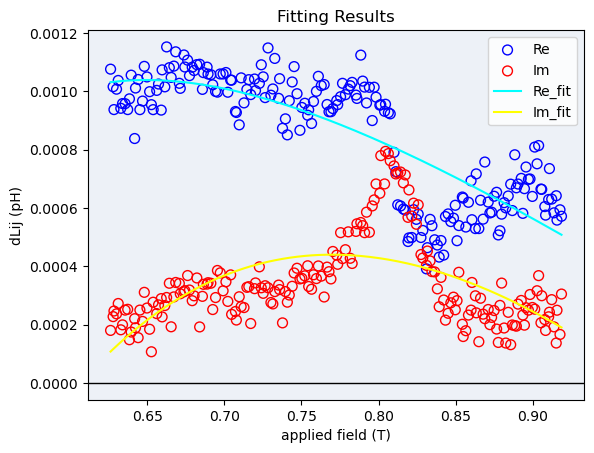


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                        0.0023         0.0065         U        No
Ai                       -0.0042         0.0096         U        No
Ho                        0.1067         0.5081         T        No
dH                        0.2000         0.2129         T        No
m                         1.5289         2.5377       1/T        No
re0                       0.0016         0.0035         U        No
im0                       0.0148         0.0172         U        No
----------------------------------------------------------------------
Index= 36, freq.=38.966 GHz, Guide field.=0.8043858192392132


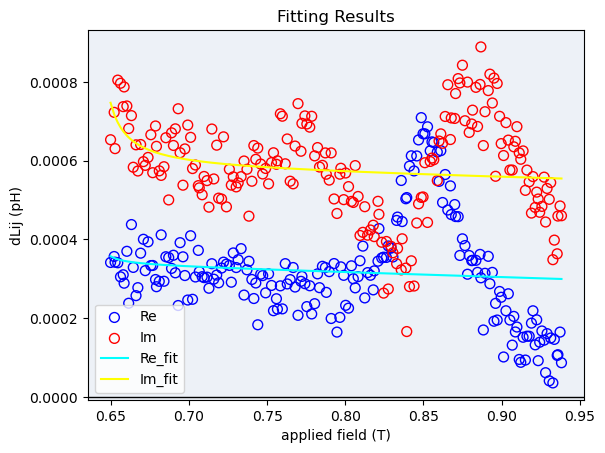


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.473e-07      1.683e-06         U        No
Ai                     1.941e-06      3.148e-06         U        No
Ho                        0.6385         0.0202         T        No
dH                     1.000e-04         0.0108         T        No
m                       -55.5761       156.9391       1/T        No
re0                    4.130e-04      1.069e-04         U        No
im0                    6.368e-04      1.742e-04         U        No
----------------------------------------------------------------------
Index= 37, freq.=39.82 GHz, Guide field.=0.8303460880288817


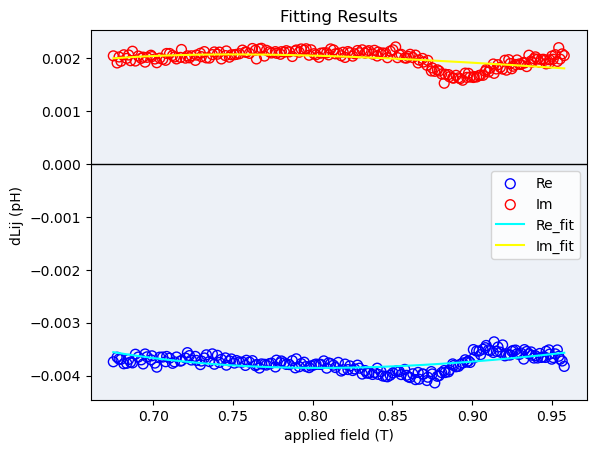


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                        0.0027         0.0059         U        No
Ai                        0.0019         0.0047         U        No
Ho                        0.2500         0.4110         T        No
dH                        0.2000         0.1750         T        No
m                         2.0560         3.1830       1/T        No
re0                      -0.0169         0.0140         U        No
im0                       0.0017         0.0028         U        No
----------------------------------------------------------------------
Index= 38, freq.=40.64 GHz, Guide field.=0.8553935665645608


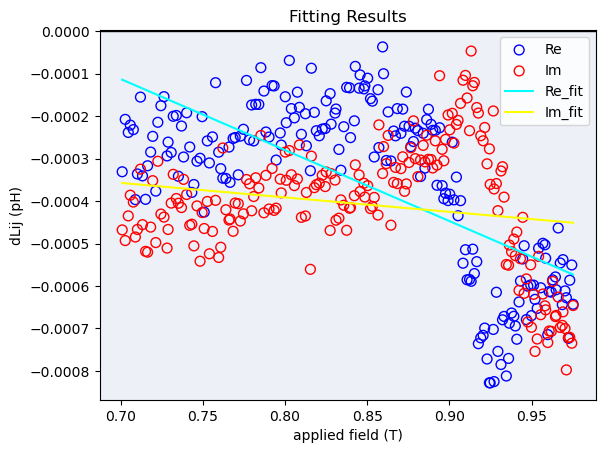


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     6.663e-07      7.133e-07         U        No
Ai                     1.006e-06      7.133e-07         U        No
Ho                     1.128e-35       239.6697         T        No
dH                     1.000e-04       239.6670         T        No
m                      -999.9999         0.0659       1/T        No
re0                       0.0011         0.0013         U        No
im0                   -1.210e-04         0.0013         U        No
----------------------------------------------------------------------
Index= 39, freq.=41.418 GHz, Guide field.=0.879262452815123


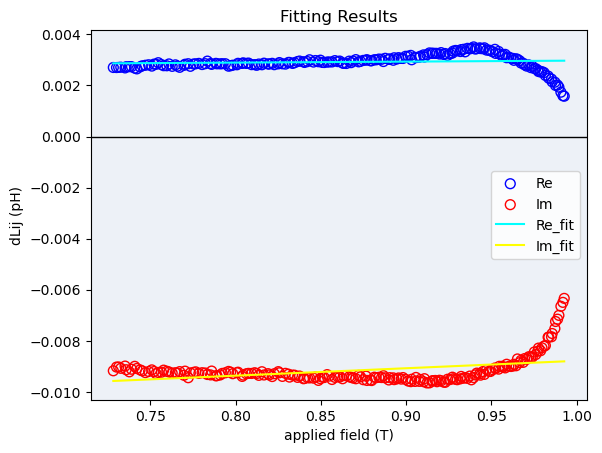


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.257e-06      2.281e-06         U        No
Ai                    -1.646e-06      2.282e-06         U        No
Ho                     2.460e-29       485.9761         T        No
dH                     1.000e-04       485.9390         T        No
m                     -1000.0000         0.1375       1/T        No
re0                       0.0026         0.0042         U        No
im0                      -0.0117         0.0042         U        No
----------------------------------------------------------------------


In [23]:
 est_gamma = 28.8 #GHz/T
 est_hx = 1500.0/1000 #T
 est_hy = -10/1000 #T

 for i in range(len(ansy1.freqs)):
     f_index = i
     freq_i = ansy1.freqs[f_index]
     H_guide = res_func.inverse_kittel_general(freq_i, est_gamma, est_hx, est_hy)

     print(f"Index= {i}, freq.={freq_i} GHz, Guide field.={H_guide}")
     ini_vals = [1, 1, H_guide, 0.028, 0, 0, 0] #Ar, Ai, Ho, dH, re0, im0


     H_min, H_max = H_guide-0.5, H_guide+0.5 #T
     h_array = ansy1.get_field(freq_i)
     y_array_re, y_array_im = ansy1.d_S("21R", freq_i), ansy1.d_S("21I", freq_i)

     model = models.ComplexLorentzian_slope_field()
     fitter = fits.ComplexFitter( ini_vals, H_min, H_max,
                                 h_array, y_array_re , y_array_im, model)
     fitter.fix(Ho=H_center, dH=0.005, re0=0, im0=0) # Parameters to be fixed, empty otherwise
     opt_p0 = fitter.simplex_wpm(method='Nelder-Mead')#'Powell'

     new_p0 = np.array(list(opt_p0.values()), dtype=float)
     fitter.update_p0(new_p0)



     params, cov = fitter.fit(simplex_b=False)
     fitter.plot_fit()
     fitter.summary()
     fit_dict = fitter.export_fit_dict()
     fits_storage.save(index=f_index, val=float(freq_i), fit_dict=fit_dict)

In [24]:
#Realoading parameters

In [203]:
data_L_fits = fits_storage.load_fit_results(newFile, group="Lorentzian fitting")

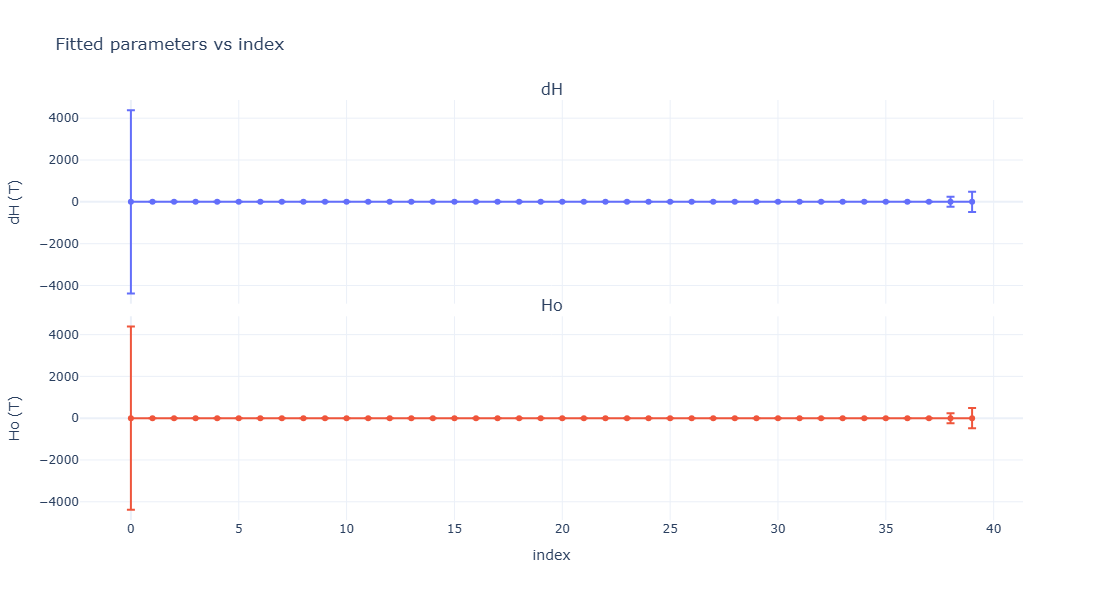

In [205]:
fits_storage.plot_fit_parameters_subplots(
    data_L_fits,
    x_axis="index",
    params=["dH", "Ho"],
    x_label= "index"#"μ₀H (T)"
)

In [207]:
cut_data_L_fits = fits_storage.slice_dict(data_L_fits, 1, 37)

In [209]:
#Plotting of fitted parameters

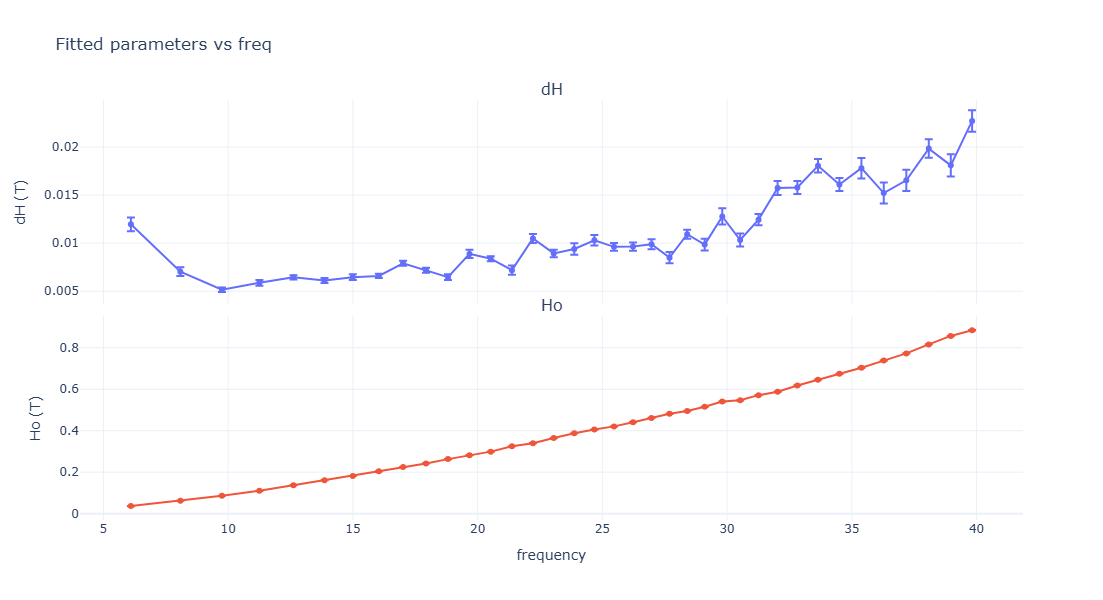

In [211]:
fits_storage.plot_fit_parameters_subplots(
    cut_data_L_fits,
    x_axis="freq",
    params=["dH", "Ho"],
    x_label= "frequency"#"(GHz)"
)